<a href="https://colab.research.google.com/github/hjiwoong/DL/blob/main/day18_practice1_%EB%A9%80%ED%8B%B0%ED%97%A4%EB%93%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# 멀티헤드 어텐션 - 여러 관점으로 보기
# 어텐션은 '관점 하나'로 관련도를 쟀다
# 그런데 단어 사이 관계는 여러 종류(문법 관계, 의미 관계, 부정 관계)
# 헤드 = 관점, 64차원을 8개 헤드로 쪼개면 각 헤드가 8차원짜리 '자기만의 Q·K·V로 서로 다른 관계를 배운다

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt

torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"

In [8]:
# 셀 1. 쪼개고, 각자 보고, 합친다
class MultiHeadAttention(nn.Module):
  def __init__(self, dim, n_heads): # dim = 64, n_heads=8 헤드 수
    super().__init__()
    assert dim % n_heads == 0 # 64/8 == 0
    self.n_heads = n_heads
    self.d_heads = dim // n_heads # d_head=8 헤드 하나가 맡는 차원 수

    self.W_q = nn.Linear(dim, dim, bias=False) # 각 헤드마다 Q,K,V를 만들 학습 행렬
    self.W_k = nn.Linear(dim, dim, bias=False)
    self.W_v = nn.Linear(dim, dim, bias=False)
    self.W_o = nn.Linear(dim, dim, bias=False) # 헤드들 결과를 합친 뒤 섞는 출력층

  def forward(self, x, mask=None):
    B, L, D = x.shape # x:(2,10,64) 배치, 단어수(Length), 벡터차원
    H, dh = self.n_heads, self.d_heads # H=8 헤드수, dh=8 각헤드 차원수

    # 1. 쪼개기 x:(2,10,64) → (2,10,8,8) → (2,8,10,8)
    Q = self.W_q(x).reshape(B, L, H, dh).transpose(1, 2) # (2,8,10,8) 배치, 멀티헤드수, 단어길이(10), 벡터차원수(8)
    K = self.W_k(x).reshape(B, L, H, dh).transpose(1, 2)
    V = self.W_v(x).reshape(B, L, H, dh).transpose(1, 2)

    # 2. 각자 보기 : 셀프어텐션
    scores = Q @ K.transpose(-2, -1) / math.sqrt(dh) # [(2,8,10,10)] (B, H, QL, KL) 관련도 점수
    if mask is not None:
      scores = scores.masked_fill(mask, -1e9) # masked_fill(조건, 값) 조건이 True인 위치를 값으로 채운다. (-10억 (-무한대))가 softmax를 통과하면 0이 된다.
    attn = F.softmax(scores, dim=-1) # softmax에서 dim=-1 축을 따라 정규화, (축은 그대로 남아있고, 그 축의 값들을 합=1로) (2,8,10Q,10K)
    self.attn_map = attn # 시각화용 저장 (2,8,10Q,10K)
    out = attn @ V # (2,8,10,8) B,H,L,dh

    # 3. 이어붙이기 : 헤드 8개(각 8차원)를 다시 원래 64차원 한 줄로 이어붙여 입력과 같은 모양 복원(2,10,64)
    out = out.transpose(1,2).reshape(B, L, D) # (2,8,10,8) → (2,10,8,8) → (2,10,64)

    # 4. 섞기 : 헤드 8개 결과를 어떻게 조합할지도 학습(W_o)
    return self.W_o(out) # (2,10,64)

In [9]:
mha = MultiHeadAttention(dim=64, n_heads=8)
x = torch.randn(2,10,64)
print("입력:", tuple(x.shape), "→ 출력:", tuple(mha(x).shape), "(모양 유지)")
n_single = sum(p.numel() for p in nn.Linear(64,64, bias=False).parameters()) * 3
n_multi = sum(p.numel() for p in mha.parameters())
print(f"파라미터: 싱글헤드(Wq,k,v) {n_single:,} → 멀티헤드 {n_multi:,}") # 늘어난 것은 W_o 하나뿐, 헤드를 늘려도 파라미터는 거의 그대로

입력: (2, 10, 64) → 출력: (2, 10, 64) (모양 유지)
파라미터: 싱글헤드(Wq,k,v) 12,288 → 멀티헤드 16,384


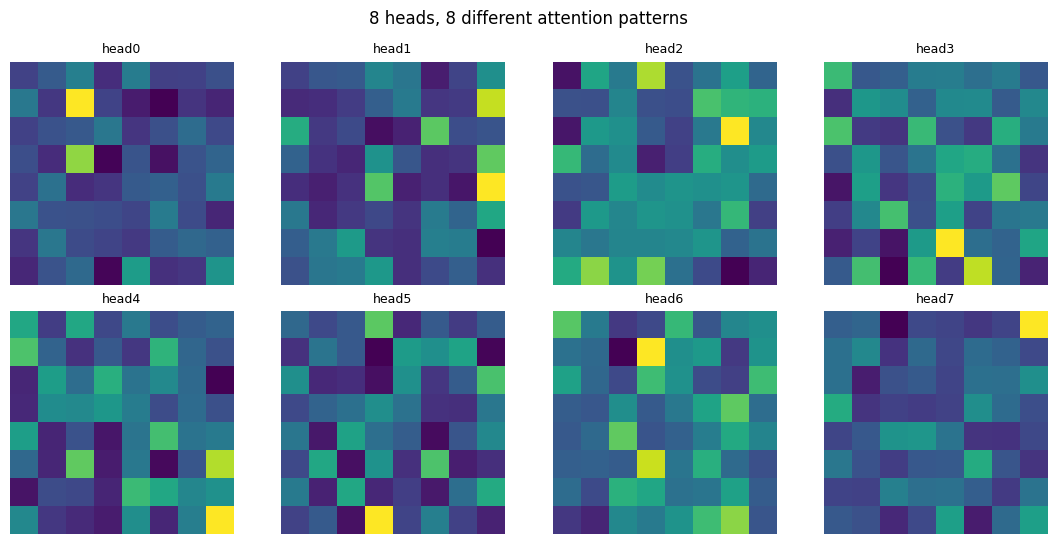

In [10]:
# 셀 2. 헤드마다 다른 곳을 본다 - 시각화
_ = mha(torch.randn(1,8,64)) # 문장1 단어8 벡터차원64
maps = mha.attn_map[0].detach() # 0번 문장(8헤드, 8Q, 8K) 관련도

fig, axes = plt.subplots(2, 4, figsize=(11,5.5))
for h, ax in enumerate(axes.flat):
  ax.imshow(maps[h], cmap="viridis")
  ax.set_title(f"head{h}", fontsize=9); ax.axis("off")
plt.suptitle("8 heads, 8 different attention patterns")
plt.tight_layout(); plt.savefig("plot1_heads.png")
plt.show()
#지금은 미학습이라 '무작위로 다름' 학습되면 각 헤드가 문법/의미/거리 같은 역할을 스스로 분담